# 🏀 March Machine Learning Mania 2026

Predicting NCAA Tournament Outcomes with Machine Learning

**Final Brier Score: 0.136 (Ranked 1246)**

This project explores how feature engineering and probabilistic evaluation can improve NCAA matchup prediction.

This notebook presents a simplified version of my March Machine Learning Mania 2026 approach.

## 🎯 Problem

The goal of this project is to predict the probability that one team beats another in NCAA tournament matchups.

Unlike traditional classification problems, this task focuses on **probabilistic predictions**, evaluated using **Brier score**, which emphasizes both accuracy and calibration.

This makes the project relevant to real-world ML systems where confidence, ranking quality, and calibration matter.


## 📊 Data

The dataset includes historical NCAA game results, team information, and performance statistics.

Key sources:
- Regular season results
- Tournament results
- Team-level performance metrics

These data were used to construct matchup-level features.

For this portfolio version, I used men's regular season results, tournament results, and tournament seeds to create matchup-level features.

In [1]:
import pandas as pd

reg = pd.read_csv("../data/MRegularSeasonCompactResults.csv")
tourney = pd.read_csv("../data/MNCAATourneyCompactResults.csv")
seeds = pd.read_csv("../data/MNCAATourneySeeds.csv")

print("Regular season games:", reg.shape)
print("Tournament games:", tourney.shape)
print("Seed rows:", seeds.shape)

Regular season games: (198577, 8)
Tournament games: (2585, 8)
Seed rows: (2694, 3)


In [2]:
reg.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


## ⚙️ Feature Engineering

Feature design played a critical role in model performance.

Key features include:
- Seed difference between teams
- Historical win rates
- Average scoring margin (point differential)

These features capture both team strength and relative matchup advantages.

In [ ]:
# Team stats
# Build team-level regular season stats
wins = reg[['Season', 'WTeamID', 'WScore', 'LScore']].copy()
wins.columns = ['Season', 'TeamID', 'Score', 'OppScore']
wins['Win'] = 1

losses = reg[['Season', 'LTeamID', 'LScore', 'WScore']].copy()
losses.columns = ['Season', 'TeamID', 'Score', 'OppScore']
losses['Win'] = 0

games = pd.concat([wins, losses], ignore_index=True)

team_stats = games.groupby(['Season', 'TeamID']).agg({
    'Win': 'mean',
    'Score': 'mean',
    'OppScore': 'mean'
}).reset_index()

team_stats = team_stats.rename(columns={'Win': 'WinRate'})
team_stats['PointDiff'] = team_stats['Score'] - team_stats['OppScore']

team_stats.head()

,Season,TeamID,WinRate,Score,OppScore,PointDiff
0,1985,1102,0.208333,63.083333,68.875000,-5.791667
1,1985,1103,0.391304,61.043478,64.086957,-3.043478
2,1985,1104,0.700000,68.500000,60.700000,7.800000
3,1985,1106,0.416667,71.625000,75.416667,-3.791667
4,1985,1108,0.760000,83.000000,75.040000,7.960000


In [4]:
# Add seed
seeds = seeds.copy()
seeds['SeedNum'] = seeds['Seed'].str[1:3].astype(int)

team_stats = team_stats.merge(
    seeds[['Season', 'TeamID', 'SeedNum']],
    on=['Season', 'TeamID'],
    how='left'
)

team_stats.head()

,Season,TeamID,WinRate,Score,OppScore,PointDiff,SeedNum
0,1985,1102,0.208333,63.083333,68.875000,-5.791667,NaN
1,1985,1103,0.391304,61.043478,64.086957,-3.043478,NaN
2,1985,1104,0.700000,68.500000,60.700000,7.800000,7.0
3,1985,1106,0.416667,71.625000,75.416667,-3.791667,NaN
4,1985,1108,0.760000,83.000000,75.040000,7.960000,NaN


In [6]:
# Build matchup features
# Build tournament matchup dataset
data = tourney.copy()
data["Team1"] = data[["WTeamID", "LTeamID"]].min(axis=1)
data["Team2"] = data[["WTeamID", "LTeamID"]].max(axis=1)
data["Result"] = (data["WTeamID"] == data["Team1"]).astype(int)

# Merge Team1 stats
data = data.merge(
    team_stats,
    left_on=["Season", "Team1"],
    right_on=["Season", "TeamID"],
    how="left"
).rename(columns={
    "WinRate": "T1_WinRate",
    "PointDiff": "T1_PointDiff",
    "SeedNum": "T1_Seed"
}).drop(columns=["TeamID", "Score", "OppScore"], errors="ignore")

# Merge Team2 stats
data = data.merge(
    team_stats,
    left_on=["Season", "Team2"],
    right_on=["Season", "TeamID"],
    how="left"
).rename(columns={
    "WinRate": "T2_WinRate",
    "PointDiff": "T2_PointDiff",
    "SeedNum": "T2_Seed"
}).drop(columns=["TeamID", "Score", "OppScore"], errors="ignore")

# Difference features
data["WinRateDiff"] = data["T1_WinRate"] - data["T2_WinRate"]
data["PointDiffDiff"] = data["T1_PointDiff"] - data["T2_PointDiff"]
data["SeedDiff"] = data["T1_Seed"] - data["T2_Seed"]

data[["Season", "Team1", "Team2", "Result", "WinRateDiff", "PointDiffDiff", "SeedDiff"]].head()

,Season,Team1,Team2,Result,WinRateDiff,PointDiffDiff,SeedDiff
0,1985,1116,1234,1,-0.030303,-6.830303,1.0
1,1985,1120,1345,1,-0.059310,-0.110345,5.0
2,1985,1207,1250,1,0.546616,20.114943,-15.0
3,1985,1229,1425,1,0.062169,2.177249,1.0
4,1985,1242,1325,1,0.025926,1.077778,-11.0


## 🤖 Modeling

I experimented with simple and interpretable models, including:

- Logistic Regression

The focus was not on model complexity, but on:
- Strong feature signals
- Stable probability outputs

In [7]:
from sklearn.linear_model import LogisticRegression

features = ["WinRateDiff", "PointDiffDiff", "SeedDiff"]

train = data[data["Season"] < 2019].dropna(subset=features + ["Result"])
test = data[data["Season"] >= 2019].dropna(subset=features + ["Result"])

X_train = train[features]
y_train = train["Result"]

X_test = test[features]
y_test = test["Result"]

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]

In [8]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
1,PointDiffDiff,0.082127
2,SeedDiff,-0.139066
0,WinRateDiff,-1.289270


## 📈 Evaluation

The model is evaluated using **Brier Score**, which measures the accuracy of probabilistic predictions.

Key observations:
- Calibration significantly impacts performance
- Overconfident predictions increase error
- Well-calibrated probabilities outperform sharper but miscalibrated predictions

In [9]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, preds)
print("Brier Score:", round(brier, 4))

Brier Score: 0.1967


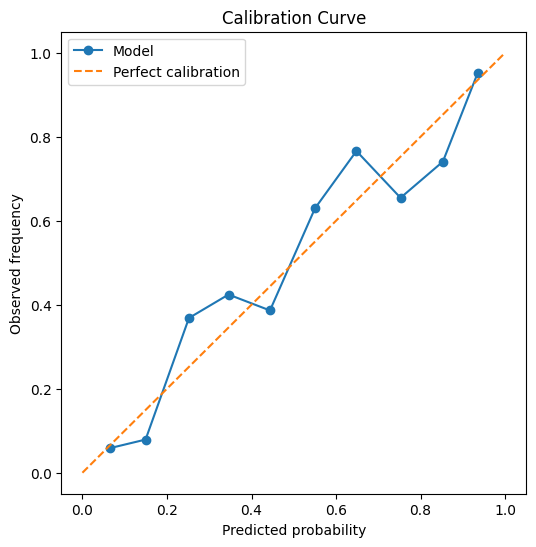

In [10]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, preds, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Curve')
plt.legend()
plt.show()

## 🏆 Results

This notebook demonstrates the portfolio version of my approach using an interpretable logistic regression model.

My final Kaggle competition submission achieved:
- **Brier Score: 0.136**
- **Leaderboard Rank: 1246**

The simplified notebook model also outperformed a 0.5 baseline and highlights the core feature engineering and evaluation logic behind the project.

In [11]:
baseline_preds = [0.5] * len(y_test)
baseline_brier = brier_score_loss(y_test, baseline_preds)

results_df = pd.DataFrame({
    "Model": ["Baseline (0.5)", "Logistic Regression"],
    "Brier Score": [baseline_brier, brier]
})

results_df

,Model,Brier Score
0,Baseline (0.5),0.250000
1,Logistic Regression,0.196677


## 🔍 Key Insights

- Feature engineering had a larger impact than model complexity
- Seed difference is a strong predictor, but not sufficient alone
- Upsets remain difficult to model due to inherent randomness
- Calibration is critical for improving probabilistic predictions

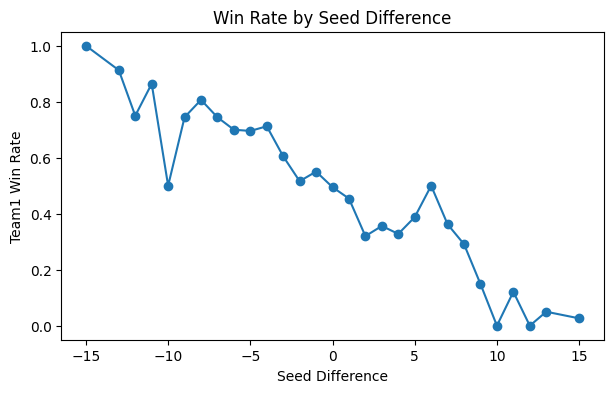

In [12]:
seed_bins = data.dropna(subset=["SeedDiff", "Result"]).copy()
seed_summary = seed_bins.groupby("SeedDiff")["Result"].mean().reset_index()

plt.figure(figsize=(7, 4))
plt.plot(seed_summary["SeedDiff"], seed_summary["Result"], marker='o')
plt.xlabel("Seed Difference")
plt.ylabel("Team1 Win Rate")
plt.title("Win Rate by Seed Difference")
plt.show()

## 🚀 Next Steps

Possible future improvements include:
- Adding Elo-based team strength features
- Applying probability calibration methods such as isotonic regression
- Comparing logistic regression with tree-based ensemble models
- Extending the approach to include women's tournament predictions